# Week 1 EDA — IDX-ML-Lab

Exploratory look at raw OHLCV data for the 5 LQ45 tickers before feature engineering begins in Week 2.

In [1]:
import os
print(os.getcwd())

c:\Semester 7\Project Iseng\IDX-ML-Lab\notebooks


In [2]:
os.chdir("..")  # pindah working directory ke root project
print(os.getcwd())

c:\Semester 7\Project Iseng\IDX-ML-Lab


In [3]:
import os
print(os.getcwd())
print(os.path.exists("data/raw"))
print(os.path.exists("../data/raw"))

c:\Semester 7\Project Iseng\IDX-ML-Lab
True
False


In [4]:
import matplotlib.pyplot as plt
import pandas as pd

from idxlab.config import load_config
from idxlab.logging_setup import setup_logging
from idxlab.data import DataLoader
from idxlab.clean import clean_ticker_data

plt.style.use("ggplot")

cfg = load_config("configs/config.yaml")
setup_logging(cfg.log_level)

In [5]:
loader = DataLoader.from_config(cfg)
raw_data = loader.load_all()

cleaned_data = {ticker: clean_ticker_data(df) for ticker, df in raw_data.items()}

list(raw_data.keys())

21:37:03 | INFO     | idxlab.data | Fetching BBCA.JK from yfinance (2023-01-01 -> 2026-09-01)
21:37:04 | INFO     | idxlab.data | Cached BBCA.JK: 870 rows -> data\raw\BBCA_JK.parquet
21:37:04 | INFO     | idxlab.data | Fetching BBRI.JK from yfinance (2023-01-01 -> 2026-09-01)
21:37:04 | INFO     | idxlab.data | Cached BBRI.JK: 871 rows -> data\raw\BBRI_JK.parquet
21:37:04 | INFO     | idxlab.data | Fetching TLKM.JK from yfinance (2023-01-01 -> 2026-09-01)
21:37:04 | INFO     | idxlab.data | Cached TLKM.JK: 871 rows -> data\raw\TLKM_JK.parquet
21:37:04 | INFO     | idxlab.data | Fetching ASII.JK from yfinance (2023-01-01 -> 2026-09-01)
21:37:04 | INFO     | idxlab.data | Cached ASII.JK: 871 rows -> data\raw\ASII_JK.parquet
21:37:04 | INFO     | idxlab.data | Fetching UNVR.JK from yfinance (2023-01-01 -> 2026-09-01)
21:37:05 | INFO     | idxlab.data | Cached UNVR.JK: 871 rows -> data\raw\UNVR_JK.parquet


['BBCA.JK', 'BBRI.JK', 'TLKM.JK', 'ASII.JK', 'UNVR.JK']

In [6]:
print(type(cleaned_data["BBCA.JK"].columns))
print(cleaned_data["BBCA.JK"].columns)

<class 'pandas.MultiIndex'>
MultiIndex([(        'Close', 'BBCA.JK'),
            (         'High', 'BBCA.JK'),
            (          'Low', 'BBCA.JK'),
            (         'Open', 'BBCA.JK'),
            (       'Volume', 'BBCA.JK'),
            ('split_suspect',        '')],
           names=['Price', 'Ticker'])


## 1. Price Trends

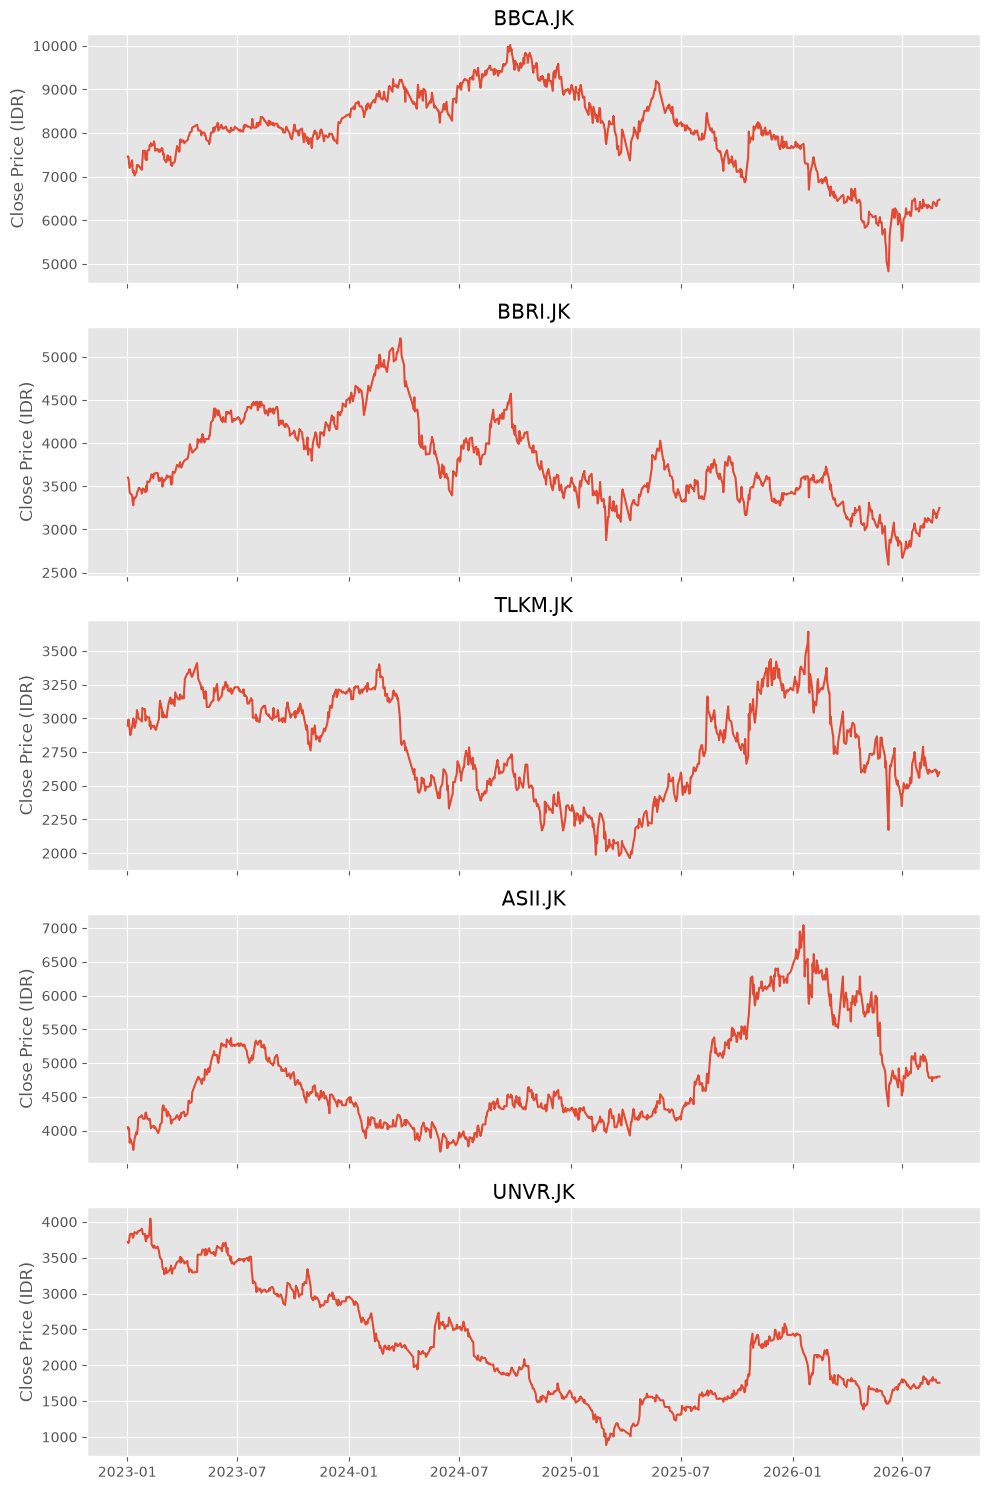

In [6]:
fig, axes = plt.subplots(len(cleaned_data), 1, figsize=(10, 3 * len(cleaned_data)), sharex=True)

for ax, (ticker, df) in zip(axes, cleaned_data.items()):
    ax.plot(df.index, df["Close"])
    ax.set_title(ticker)
    ax.set_ylabel("Close Price (IDR)")

plt.tight_layout()
plt.show()

## 2. Volume Trends

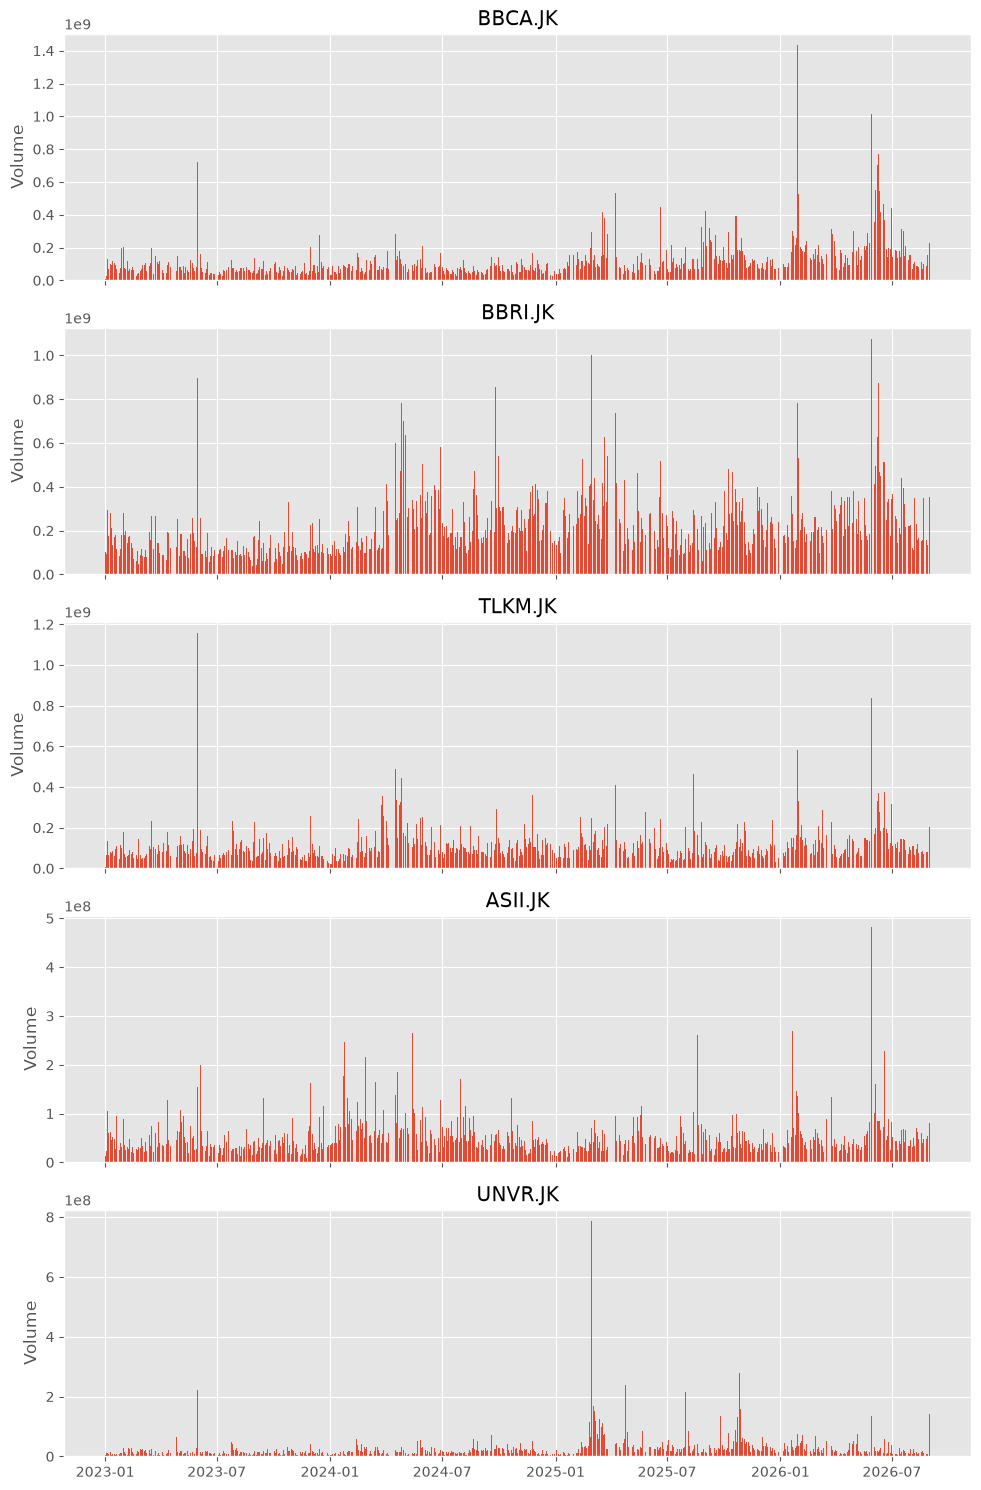

In [7]:
fig, axes = plt.subplots(len(cleaned_data), 1, figsize=(10, 3 * len(cleaned_data)), sharex=True)

for ax, (ticker, df) in zip(axes, cleaned_data.items()):
    ax.bar(df.index, df["Volume"], width=1.0)
    ax.set_title(ticker)
    ax.set_ylabel("Volume")

plt.tight_layout()
plt.show()

## 3. Missing-Data Report

Comparing raw (pre-cleaning) vs. cleaned data, plus what the cleaning pipeline flagged.

In [8]:
report_rows = []

for ticker in raw_data:
    raw_df = raw_data[ticker]
    clean_df = cleaned_data[ticker]

    report_rows.append({
        "ticker": ticker,
        "raw_rows": len(raw_df),
        "raw_missing_values": int(raw_df.isna().sum().sum()),
        "duplicate_dates": int(raw_df.index.duplicated().sum()),
        "clean_rows": len(clean_df),
        "rows_dropped": len(raw_df) - len(clean_df),
        "split_suspect_flagged": int(clean_df["split_suspect"].sum()),
    })

report_df = pd.DataFrame(report_rows).set_index("ticker")
report_df

,raw_rows,raw_missing_values,duplicate_dates,clean_rows,rows_dropped,split_suspect_flagged
ticker,,,,,,
BBCA.JK,870,0,0,870,0,0
BBRI.JK,871,0,0,871,0,0
TLKM.JK,871,0,0,871,0,0
ASII.JK,871,0,0,871,0,0
UNVR.JK,871,0,0,871,0,0


## 4. Observations
Didn't expect the data to be this clean. No missing / duplicate values. 
After reaching it's peak, both BBCA and BBRI are going in a downtrend.
TLKM and ASII had a really similar pattern, reaching it's peak when the volume stonks.
UNVR are going in a downtrend at first, but managed to rebound (a little).